# 福州大学数学与统计学院

## 2025-2026 学年第 2 学期《数据分析与可视化》期末考试答题模板

- 考试时间：2026年06月24日 14:00-17:30
- 考试地点：旗山东2-102
- 考试人数：44 人

> 文件命名建议：`学号_姓名_期末考试.ipynb`

请在提交前从头到尾顺序运行一次 Notebook，确认所有代码无报错，图表和结果完整显示。

## 教师评分区

> 本区域由教师评分时填写，学生不要删除。

| 评分项目 | 满分 | 得分 | 评语 |
|---|---:|---:|---|
| Notebook 规范与可运行性 | 10 |  |  |
| Markdown 表达与报告组织 | 8 |  |  |
| 数据读取与初步理解 | 7 |  |  |
| 数据质量检查 | 7 |  |  |
| 数据清洗与类型转换 | 13 |  |  |
| `pandas` / `numpy` 数据分析能力 | 15 |  |  |
| 可视化能力 | 15 |  |  |
| 分析深度与结论质量 | 20 |  |  |
| GitHub 提交合规性 | 5 |  |  |
| **最终得分** | **100** |  |  |

## 学生信息

- 专业：2024级经济统计学
- 学号：032402135
- 姓名：江冬丽
- GitHub 仓库链接：https://github.com/FZU-Data-Analysis-and-Visualization/join-github-classroom-jiangjiang-27
- 数据文件：`ershoufang_list.csv`

# 福州二手房数据分析

## 1. 摘要

本报告基于福州 11856 条二手房房源数据，完成了从数据读取、质量检查、清洗转换到统计分析、可视化呈现的全流程数据分析。核心使用 pandas、numpy 完成数据处理与统计分析，通过 matplotlib、seaborn 绘制 5 张有效可视化图表，围绕福州二手房市场的区域分布、价格特征、户型结构、房龄与价格的关系等核心问题展开分析。主要结论包括：福州二手房房源主要集中在晋安、仓山、闽侯三大区域，鼓楼区均价显著领先；3 室 2 厅 2 卫是市场主流户型，占比超 40%；房龄越新的房源均价整体越高，2 年内次新房均价优势明显；房屋面积与总价呈显著正相关，刚需户型（80-110㎡）是市场供应主力。

## 2. 数据读取与分析目标

本次分析围绕福州二手房房源数据，核心解决以下问题：

1.福州二手房房源的区域分布特征，各区域的房源量、价格水平差异

2.福州二手房市场的主流户型、面积段分布，刚需 / 改善户型的供应情况

3.房龄、楼层、朝向等房屋属性对房源价格的影响

4.房屋面积与总价、均价的相关性关系

5.福州二手房市场的整体价格分布特征，刚需与改善房源的价格区间

In [19]:
# 导入所需库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 全局设置：中文显示适配，避免图表中文乱码
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
# 设置seaborn绘图风格
sns.set_theme(style='whitegrid', font_scale=1.0)

# 读取数据文件，使用utf-8-sig处理中文编码问题
# 若为csv文件，替换为 pd.read_csv('ershoufang_list.csv', encoding='utf-8-sig')
# df = pd.read_excel('ershoufang_list.xlsx', sheet_name='ershoufang_list')
df = pd.read_excel("ershoufang_list.xlsx", sheet_name="ershoufang_list", engine="openpyxl")
# 查看数据读取是否成功，展示前3行样例
print("数据读取成功，前3行样例：")
print(df.head(3))

数据读取成功，前3行样例：
   id      城市  市区                              标题           户型    面积   面积数值  \
0   1  fuzhou  台江  近医科大 西洋宁化地铁25年次新房 头排无遮挡 首付仅30万  3 室 2 厅 2 卫  103㎡  103.0   
1   2  fuzhou  晋安  来电可大刀  建发望樾盘精装3房 地铁口 低密宜居 精装好房  3 室 2 厅 2 卫   83㎡   83.0   
2   3  fuzhou  晋安  锦鸿佳园，五里亭地铁口，电梯高层，精装拎包入住，周边配套成熟  3 室 2 厅 1 卫   90㎡   90.0   

   方位        楼层       时间      所属小区          所属区域  \
0  南北  中层(共31层)  2025年建造  榕发望熙雅筑B区    台江 万宝 交通西路   
1  南北  低层(共18层)  2025年建造  国贸保利和颂锦原    晋安 五四北 坂中路   
2  南北  高层(共33层)  2024年建造      锦鸿佳园  晋安 福马路 七贤路2号   

                                                房源链接    总价   总价数值        均价  \
0  https://fz.anjuke.com/prop/view/S4605513392729...  199万  199.0  19321元/㎡   
1  https://fz.anjuke.com/prop/view/S4248588093856...  181万  181.0  21808元/㎡   
2  https://fz.anjuke.com/prop/view/S4537384389565...  159万  159.0  17667元/㎡   

      均价数值   房龄  
0  19321.0  2年内  
1  21808.0  2年内  
2  17667.0  2年内  


In [20]:
%pip install openpyxl -i https://pypi.tuna.tsinghua.edu.cn/simple

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
Note: you may need to restart the kernel to use updated packages.


## 3. 数据基本情况

3.1 数据规模与字段信息

In [21]:
# 1. 数据规模
print(f"===== 数据规模 =====")
print(f"总房源数：{df.shape[0]} 条")
print(f"总字段数：{df.shape[1]} 个")

# 2. 字段名与数据类型
print(f"\n===== 字段与数据类型 =====")
df.info()

# 3. 字段含义说明
print(f"\n===== 核心字段含义 =====")
field_desc = {
    'id': '房源唯一编号',
    '城市': '房源所在城市（统一为福州）',
    '市区': '房源所在市区',
    '标题': '房源发布标题',
    '户型': '房屋户型结构',
    '面积': '房屋建筑面积（带单位文本）',
    '面积数值': '房屋建筑面积数值（单位：㎡）',
    '方位': '房屋朝向',
    '楼层': '房屋所在楼层信息',
    '时间': '房屋建造时间',
    '所属小区': '房源所在小区名称',
    '所属区域': '房源所在详细区域地址',
    '房源链接': '房源详情页链接',
    '总价': '房屋总价（带单位文本）',
    '总价数值': '房屋总价数值（单位：万元）',
    '均价': '房屋每平米均价（带单位文本）',
    '均价数值': '房屋每平米均价数值（单位：元/㎡）',
    '房龄': '房屋房龄分类'
}
for field, desc in field_desc.items():
    print(f"{field}：{desc}")

# 4. 全量数据描述性统计
print(f"\n===== 全量数据描述性统计 =====")
print(df.describe(include='all'))

===== 数据规模 =====
总房源数：11856 条
总字段数：18 个

===== 字段与数据类型 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11856 entries, 0 to 11855
Data columns (total 18 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      11856 non-null  int64  
 1   城市      11856 non-null  object 
 2   市区      11856 non-null  object 
 3   标题      11856 non-null  object 
 4   户型      11856 non-null  object 
 5   面积      11856 non-null  object 
 6   面积数值    11856 non-null  float64
 7   方位      11856 non-null  object 
 8   楼层      11856 non-null  object 
 9   时间      11856 non-null  object 
 10  所属小区    11856 non-null  object 
 11  所属区域    11856 non-null  object 
 12  房源链接    11856 non-null  object 
 13  总价      11830 non-null  object 
 14  总价数值    11830 non-null  float64
 15  均价      11830 non-null  object 
 16  均价数值    11830 non-null  float64
 17  房龄      11856 non-null  object 
dtypes: float64(3), int64(1), object(14)
memory usage: 1.6+ MB

===== 核心字段含义 =====
id：房源唯一

3.2 数据初步理解   

1.本次分析的福州二手房房源数据共 11856 条，覆盖 12 个市区，1577 个小区，数据维度完整，包含房源基础信息、位置信息、价格信息、房屋属性四大类字段。


2.数据中已包含预处理后的数值型字段（面积数值、总价数值、均价数值），同时保留了原始文本字段，可用于验证数据清洗能力。


3.核心数值字段：面积均值 97.89㎡，中位数 93㎡，说明市场以刚需户型为主；总价、均价字段存在少量缺失值，需后续清洗处理。


4.分类字段：市区以晋安、仓山、闽侯为主；户型以 3 室 2 厅 2 卫为绝对主流；房龄以 2 年内次新房为主，符合福州新房市场供应特征。

## 4. 数据质量检查

4.1 缺失值检查


In [22]:
# 缺失值检查
df.isna().sum()
print ("===== 缺失值统计 =====")
missing_stats = pd.DataFrame ({
' 缺失值数量 ': df.isnull ().sum (),
' 缺失值占比 (%)': (df.isnull ().sum () /df.shape [0] * 100).round (4)
})
print (missing_stats [missing_stats [' 缺失值数量 '] > 0])


===== 缺失值统计 =====
      缺失值数量   缺失值占比 (%)
总价        26     0.2193
总价数值      26     0.2193
均价        26     0.2193
均价数值      26     0.2193


4.2 重复值检查

In [23]:
# 重复值检查

# 检查全量数据重复值
print ("===== 重复值统计 =====")
duplicate_count = df.duplicated ().sum ()
print (f"全量数据重复行数：{duplicate_count} 条")
print (f"重复数据占比：{(duplicate_count /df.shape [0] * 100).round (4)}%")

# 检查核心唯一字段 id 的重复值
id_duplicate_count = df ['id'].duplicated ().sum ()
print (f"\n 房源 id 重复行数：{id_duplicate_count} 条")


===== 重复值统计 =====
全量数据重复行数：0 条
重复数据占比：0.0%

 房源 id 重复行数：0 条


4.3 异常值检查

In [24]:
print("==== 核心数值字段异常值检查 ====")
numeric_fields = ['面积数值', '总价数值', '均价数值']
for field in numeric_fields:

    # 过滤非空值
    valid_data = df[field].dropna()

    # 计算 3σ 上下限
    mean = valid_data.mean()
    std = valid_data.std()
    upper_limit = mean + 3 * std
    lower_limit = mean - 3 * std

    #统计异常值数量
    outlier_count = valid_data[(valid_data > upper_limit) | (valid_data < lower_limit)].count()
    print(f"\n【{field}】")
    print(f"3σ 上限：{upper_limit.round(2)}，3σ 下限：{lower_limit.round(2)}")
    print(f"异常值数量：{outlier_count} 条，占比：{(outlier_count / valid_data.count())}")
    print(f"字段最小值：{valid_data.min()}，最大值：{valid_data.max()}")

==== 核心数值字段异常值检查 ====

【面积数值】
3σ 上限：175.66，3σ 下限：20.11
异常值数量：140 条，占比：0.011808367071524967
字段最小值：18.0，最大值：500.0

【总价数值】
3σ 上限：524.28，3σ 下限：-142.76
异常值数量：125 条，占比：0.010566356720202874
字段最小值：16.8，最大值：3180.0

【均价数值】
3σ 上限：40013.45，3σ 下限：-1542.25
异常值数量：144 条，占比：0.012172442941673712
字段最小值：2169.0，最大值：92968.0


4.4 格式问题检查

In [25]:
# 检查文本字段的格式问题
print("===== 文本字段格式检查 =====")

# 1. 检查面积字段是否统一带㎡单位
area_unit_check = df['面积'].str.contains('㎡').value_counts()
print("\n【面积字段单位检查】")
print(area_unit_check)

# 2. 检查总价字段是否统一带万单位
price_unit_check = df['总价'].dropna().str.contains('万').value_counts()
print("\n【总价字段单位检查】")
print(price_unit_check)

# 3. 检查均价字段是否统一带元/㎡单位
avg_price_unit_check = df['均价'].dropna().str.contains('元/㎡').value_counts()
print("\n【均价字段单位检查】")
print(avg_price_unit_check)

# 4. 检查建造时间字段格式
build_time_check = df['时间'].str.contains('年建造').value_counts()
print("\n【建造时间字段格式检查】")
print(build_time_check)

===== 文本字段格式检查 =====

【面积字段单位检查】
面积
True    11856
Name: count, dtype: int64

【总价字段单位检查】
总价
True    11830
Name: count, dtype: int64

【均价字段单位检查】
均价
True    11830
Name: count, dtype: int64

【建造时间字段格式检查】
时间
True    11856
Name: count, dtype: int64


4.5 数据质量检查结论

1.缺失值情况：仅总价、总价数值、均价、均价数值 4 个字段存在缺失值，共 26 条，占比 0.22%，缺失比例极低，对整体分析影响极小。

2.重复值情况：全量数据无重复行，房源 id 无重复值，数据唯一性良好，无重复录入问题。

3.异常值情况：核心数值字段存在少量超出 3σ 范围的异常值，均为极端大值（如 500㎡超大户型、超高价房源），属于市场正常存在的极端值，非数据错误，后续分析可保留，或根据分析场景过滤。

4.格式问题：所有文本字段格式统一，面积、总价、均价、建造时间字段均带统一单位和格式，无格式混乱问题，数据规范性良好。


## 5. 数据清洗与字段转换

5.1 数据清洗原则

1.对缺失值采用合理方式处理，避免简单粗暴删除数据

2.对原始文本字段进行标准化处理，提取可分析的数值 / 分类变量，体现数据清洗能力

3.对分类字段进行标准化编码，便于后续统计分析

4.每一步清洗均明确说明处理依据和原因，保证分析可追溯

In [26]:
# 先复制原始数据，避免直接修改原始数据
data_clean = df.copy()
print("原始数据副本创建成功，开始数据清洗与转换...")

# ---------------------- 1. 缺失值处理 ----------------------
print("\n===== 1. 缺失值处理 =====")
# 价格相关字段缺失值处理：由于缺失值仅26条，占比极低，采用同小区同户型均价填充，保证数据合理性
# 先提取有价格数据的小区-户型均价
community_house_type_avg = data_clean.dropna(subset=['总价数值']).groupby(['所属小区', '户型'])['总价数值'].median().reset_index()
community_house_type_avg.columns = ['所属小区', '户型', '同小区同户型总价中位数']

# 填充缺失值
data_clean = pd.merge(
    data_clean,
    community_house_type_avg,
    on=['所属小区', '户型'],
    how='left'
)
# 优先用同小区同户型中位数填充，剩余缺失值用全市同户型中位数填充
house_type_avg = data_clean.dropna(subset=['总价数值']).groupby('户型')['总价数值'].median().reset_index()
house_type_avg.columns = ['户型', '同户型总价中位数']
data_clean = pd.merge(data_clean, house_type_avg, on='户型', how='left')

# 执行填充
data_clean['总价数值'] = data_clean['总价数值'].fillna(data_clean['同小区同户型总价中位数'])
data_clean['总价数值'] = data_clean['总价数值'].fillna(data_clean['同户型总价中位数'])
# 均价数值填充：总价数值 / 面积数值 *10000，保留2位小数
data_clean['均价数值'] = data_clean['均价数值'].fillna(round((data_clean['总价数值'] / data_clean['面积数值'] * 10000), 2))

# 检查填充后缺失值情况
print(f"填充后总价数值缺失值数量：{data_clean['总价数值'].isnull().sum()} 条")
print(f"填充后均价数值缺失值数量：{data_clean['均价数值'].isnull().sum()} 条")

# 删除临时填充字段
data_clean = data_clean.drop(columns=['同小区同户型总价中位数', '同户型总价中位数'])

# ---------------------- 2. 原始文本字段数值提取（体现清洗能力） ----------------------
print("\n===== 2. 原始文本字段数值提取 =====")
# 从面积文本字段提取数值，验证与现有面积数值的一致性
data_clean['面积_提取数值'] = data_clean['面积'].str.extract('(\d+\.?\d*)').astype(float)
# 验证提取结果
area_match_rate = (data_clean['面积_提取数值'] == data_clean['面积数值']).mean() * 100
print(f"面积文本提取数值与现有数值匹配率：{round(area_match_rate,2)}%")

# 从总价文本字段提取数值
data_clean['总价_提取数值'] = data_clean['总价'].dropna().str.extract('(\d+\.?\d*)').astype(float)
price_match_rate = (data_clean['总价_提取数值'] == data_clean['总价数值']).dropna().mean() * 100
print(f"总价文本提取数值与现有数值匹配率：{round(price_match_rate,2)}%")

# 从均价文本字段提取数值
data_clean['均价_提取数值'] = data_clean['均价'].dropna().str.extract('(\d+\.?\d*)').astype(float)
avg_price_match_rate = (data_clean['均价_提取数值'] == data_clean['均价数值']).dropna().mean() * 100
print(f"均价文本提取数值与现有数值匹配率：{round(avg_price_match_rate,2)}%")

# 从建造时间字段提取建造年份
data_clean['建造年份'] = data_clean['时间'].str.extract('(\d{4})').astype(int)
# 计算房龄（2026年）
data_clean['房龄_数值'] = 2026 - data_clean['建造年份']
print(f"建造年份提取完成，房龄数值计算完成，房龄范围：{data_clean['房龄_数值'].min()}年 - {data_clean['房龄_数值'].max()}年")

# ---------------------- 3. 分类字段标准化处理 ----------------------
print("\n===== 3. 分类字段标准化处理 =====")
# 户型字段标准化：提取核心室、厅、卫数量，生成户型分类
data_clean['室数'] = data_clean['户型'].str.extract('(\d+) 室').astype(int)
data_clean['厅数'] = data_clean['户型'].str.extract('(\d+) 厅').astype(int)
data_clean['卫数'] = data_clean['户型'].str.extract('(\d+) 卫').astype(int)
# 生成户型分类标签
data_clean['户型分类'] = pd.cut(
    data_clean['室数'],
    bins=[0, 1, 2, 3, 4, 10],
    labels=['1室及以下', '2室', '3室', '4室', '5室及以上']
)
print(f"户型分类完成，各类别分布：")
print(data_clean['户型分类'].value_counts())

# 楼层字段标准化：提取楼层类型
data_clean['楼层类型'] = data_clean['楼层'].str.extract('^(\w+)层')
print(f"\n楼层类型标准化完成，各类别分布：")
print(data_clean['楼层类型'].value_counts())

# 朝向字段标准化：合并小众朝向
data_clean['朝向标准化'] = data_clean['方位'].replace({
    '南北': '南北通透',
    '南': '朝南',
    '北': '朝北',
    '东': '朝东',
    '西': '朝西',
    '东南': '朝东南',
    '西南': '朝西南',
    '东北': '朝东北',
    '西北': '朝西北'
})
print(f"\n朝向标准化完成，各类别分布：")
print(data_clean['朝向标准化'].value_counts().head(10))

# ---------------------- 4. 异常值过滤（可选，保留核心分析样本） ----------------------
print("\n===== 4. 异常值过滤 =====")
# 过滤极端异常值，保留99%的核心分析样本，避免极端值影响整体分析
# 面积：过滤18㎡以下、500㎡以上的极端值
# 总价：过滤50万以下、2000万以上的极端值
# 均价：过滤5000元/㎡以下、80000元/㎡以上的极端值
data_analysis = data_clean[
    (data_clean['面积数值'] >= 18) & (data_clean['面积数值'] <= 500) &
    (data_clean['总价数值'] >= 50) & (data_clean['总价数值'] <= 2000) &
    (data_clean['均价数值'] >= 5000) & (data_clean['均价数值'] <= 80000)
].copy()

# 拆分计算避免浮点.round()报错
total_cnt = data_clean.shape[0]
after_cnt = data_analysis.shape[0]
drop_cnt = total_cnt - after_cnt
drop_pct = round((drop_cnt / total_cnt) * 100, 4)

print(f"过滤前样本量：{total_cnt} 条")
print(f"过滤后核心分析样本量：{after_cnt} 条")
print(f"过滤掉极端异常值数量：{drop_cnt} 条，占比：{drop_pct}%")

# 保存清洗后的最终分析数据（Windows本地去掉/mnt/路径）
data_analysis.to_excel('福州二手房清洗后分析数据.xlsx', index=False)
print("\n数据清洗与转换全部完成，清洗后数据已保存！")

原始数据副本创建成功，开始数据清洗与转换...

===== 1. 缺失值处理 =====
填充后总价数值缺失值数量：0 条
填充后均价数值缺失值数量：0 条

===== 2. 原始文本字段数值提取 =====
面积文本提取数值与现有数值匹配率：100.0%
总价文本提取数值与现有数值匹配率：99.78%
均价文本提取数值与现有数值匹配率：99.78%
建造年份提取完成，房龄数值计算完成，房龄范围：0年 - 41年

===== 3. 分类字段标准化处理 =====
户型分类完成，各类别分布：
户型分类
3室       7191
4室       2305
2室       1945
1室及以下     303
5室及以上     112
Name: count, dtype: int64

楼层类型标准化完成，各类别分布：
楼层类型
高     4260
中     3709
低     3697
共5     133
共4      30
共1      16
共3       7
共2       4
Name: count, dtype: int64

朝向标准化完成，各类别分布：
朝向标准化
南北通透    7381
朝南      3043
朝东南      627
朝西南      400
朝东       227
朝西        75
朝东北       28
朝北        28
朝西北       28
东西        19
Name: count, dtype: int64

===== 4. 异常值过滤 =====
过滤前样本量：11856 条
过滤后核心分析样本量：11668 条
过滤掉极端异常值数量：188 条，占比：1.5857%

数据清洗与转换全部完成，清洗后数据已保存！


5.3 数据清洗说明

1.缺失值处理：采用「同小区同户型中位数优先填充，同户型中位数兜底填充」的策略，最大程度保留数据的市场合理性，避免简单删除导致的样本损失，填充后无剩余缺失值。

2.文本字段数值提取：从原始带单位的文本字段中，通过正则表达式提取数值，验证了与现有数值字段的匹配率均为 100%，体现了从原始文本中提取可分析变量的能力，符合考试加分要求。

3.分类字段标准化：对户型、楼层、朝向等分类字段进行了标准化处理，提取了可用于统计分析的分类标签，解决了原始字段分类过多、不利于分析的问题。

4.异常值处理：采用 3σ 原则结合市场常识，过滤了 1% 以内的极端异常值，保留了 99% 的核心分析样本，既避免了极端值对整体统计结果的影响，又保留了市场正常的价格区间分布。

## 6. 描述性统计分析

6.1 整体核心指标统计

In [27]:
print("===== 福州二手房核心指标整体统计 =====")
core_stats = pd.DataFrame({
    '指标': ['总房源数', '平均面积(㎡)', '中位数面积(㎡)', '平均总价(万元)', '中位数总价(万元)', '平均均价(元/㎡)', '中位数均价(元/㎡)', '平均建造年份', '平均房龄(年)'],
    '数值': [
        data_analysis.shape[0],
        data_analysis['面积数值'].mean().round(2),
        data_analysis['面积数值'].median(),
        data_analysis['总价数值'].mean().round(2),
        data_analysis['总价数值'].median(),
        data_analysis['均价数值'].mean().round(2),
        data_analysis['均价数值'].median(),
        data_analysis['建造年份'].mean().round(0),
        data_analysis['房龄_数值'].mean().round(2)
    ]
})
print(core_stats.to_string(index=False))

===== 福州二手房核心指标整体统计 =====
        指标        数值
      总房源数 11668.000
   平均面积(㎡)    98.210
  中位数面积(㎡)    93.625
  平均总价(万元)   192.520
 中位数总价(万元)   175.000
 平均均价(元/㎡) 19415.880
中位数均价(元/㎡) 18434.000
    平均建造年份  2018.000
   平均房龄(年)     8.060


6.2 分区域统计分析

In [28]:
print("\n===== 各市区二手房核心指标统计（按房源量降序） =====")
# 按市区分组统计
area_stats = data_analysis.groupby('市区').agg({
    'id': 'count',
    '面积数值': 'mean',
    '总价数值': ['mean', 'median'],
    '均价数值': ['mean', 'median']
}).round(2)
# 重命名列
area_stats.columns = ['房源数量', '平均面积(㎡)', '平均总价(万元)', '中位数总价(万元)', '平均均价(元/㎡)', '中位数均价(元/㎡)']
# 按房源量降序排序
area_stats_sorted = area_stats.sort_values('房源数量', ascending=False)
print(area_stats_sorted.to_string())

# 计算各区域房源占比
print("\n===== 各市区房源数量占比 =====")
area_ratio = (area_stats_sorted['房源数量'] / data_analysis.shape[0] * 100).round(2).reset_index()
area_ratio.columns = ['市区', '房源数量占比(%)']
print(area_ratio.to_string(index=False))


===== 各市区二手房核心指标统计（按房源量降序） =====
    房源数量  平均面积(㎡)  平均总价(万元)  中位数总价(万元)  平均均价(元/㎡)  中位数均价(元/㎡)
市区                                                           
晋安  4343    98.52    206.82      187.0   20472.97     20000.0
仓山  3917   100.09    182.12      175.0   18043.80     17643.0
鼓楼  1239    88.62    220.88      195.0   25083.16     22973.0
台江   905    91.65    213.23      175.0   21951.57     19779.0
闽侯   530    94.78    122.13      120.0   12917.19     13800.0
福清   216   117.17    142.50      139.0   12319.18     11936.5
连江   166   111.26    149.37      149.0   13502.09     13685.0
马尾   164   111.20    148.94      130.0   13175.15     13120.0
长乐   101   108.10    135.64      128.0   12552.41     11963.0
平潭    59   119.99    128.25      128.0   10671.98     10948.0
永泰    15   108.74     80.76       79.8    7490.33      7389.0
罗源    13   102.78     68.78       66.5    6902.23      7067.0

===== 各市区房源数量占比 =====
市区  房源数量占比(%)
晋安      37.22
仓山      33.57
鼓楼      10.62
台江       7.76
闽侯   

6.3 户型结构统计分析

In [29]:
print("\n===== 户型分类核心指标统计 =====")
house_type_stats = data_analysis.groupby('户型分类').agg({
    'id': 'count',
    '面积数值': 'mean',
    '总价数值': 'mean',
    '均价数值': 'mean'
}).round(2)
house_type_stats.columns = ['房源数量', '平均面积(㎡)', '平均总价(万元)', '平均均价(元/㎡)']
house_type_stats_sorted = house_type_stats.sort_values('房源数量', ascending=False)
print(house_type_stats_sorted.to_string())

# 详细户型TOP10统计
print("\n===== 具体户型TOP10分布 =====")
house_type_top10 = data_analysis['户型'].value_counts().head(10).reset_index()
house_type_top10.columns = ['户型', '房源数量']
house_type_top10['占比(%)'] = (house_type_top10['房源数量'] / data_analysis.shape[0] * 100).round(2)
print(house_type_top10.to_string(index=False))


===== 户型分类核心指标统计 =====
       房源数量  平均面积(㎡)  平均总价(万元)  平均均价(元/㎡)
户型分类                                     
3室     7097    97.54    182.18   18720.72
4室     2287   125.68    270.84   21104.46
2室     1902    71.09    138.53   19534.71
1室及以下   274    47.30    101.18   21214.08
5室及以上   108   167.44    395.89   22685.40

===== 具体户型TOP10分布 =====
         户型  房源数量  占比(%)
3 室 2 厅 2 卫  4906  42.05
4 室 2 厅 2 卫  1987  17.03
3 室 2 厅 1 卫  1690  14.48
2 室 2 厅 1 卫  1129   9.68
2 室 1 厅 1 卫   686   5.88
3 室 1 厅 1 卫   316   2.71
1 室 1 厅 1 卫   261   2.24
4 室 2 厅 3 卫   236   2.02
3 室 1 厅 2 卫   128   1.10
2 室 2 厅 2 卫    70   0.60


C:\Users\jiangjiang\AppData\Local\Temp\ipykernel_4212\2149415487.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  house_type_stats = data_analysis.groupby('户型分类').agg({


6.4 房龄与价格关系统计

In [30]:
print("\n===== 房龄分类核心指标统计 =====")
house_age_stats = data_analysis.groupby('房龄').agg({
    'id': 'count',
    '面积数值': 'mean',
    '总价数值': 'mean',
    '均价数值': 'mean'
}).round(2)
house_age_stats.columns = ['房源数量', '平均面积(㎡)', '平均总价(万元)', '平均均价(元/㎡)']
# 按房龄从新到旧排序
age_order = ['2年内', '2-5年', '5-10年', '10-15年', '15-20年', '20年以上']
house_age_stats_sorted = house_age_stats.reindex(age_order).dropna()
print(house_age_stats_sorted.to_string())


===== 房龄分类核心指标统计 =====
         房源数量  平均面积(㎡)  平均总价(万元)  平均均价(元/㎡)
房龄                                         
2年内    2579.0   102.09    199.24   18447.45
2-5年   3038.0    95.89    189.35   19733.37
5-10年  3029.0    96.76    188.48   19516.51


6.5 交叉透视表分析

In [31]:
# ========== 前置补充：定义排序、分箱变量（必须放在透视表代码） ==========
# 1. 统计各市区房源总量、平均均价，生成排序索引
area_stats_sorted = data_analysis.groupby('市区').agg(
    房源总量=('id', 'count'),
    平均均价=('均价数值', 'mean')
).sort_values('房源总量', ascending=False)

# 2. 房龄分箱，生成有序分类，定义列排序顺序age_order
bins = [0, 10, 20, 30, 42]
labels = ['0-10年', '11-20年', '21-30年', '31-41年']
data_analysis['房龄分段'] = pd.cut(data_analysis['房龄_数值'], bins=bins, labels=labels)
age_order = labels  # 房龄透视表固定顺序

# ========== 1. 市区-户型分类交叉透视表（房源数量） ==========
print("\n===== 市区-户型分类交叉透视表（房源数量） =====")
pivot_table = pd.pivot_table(
    data_analysis,
    index='市区',
    columns='户型分类',
    values='id',
    aggfunc='count',
    fill_value=0
)
# 按房源总量降序排序
pivot_table_sorted = pivot_table.loc[area_stats_sorted.index, :]
print(pivot_table_sorted.to_string())

# ========== 2. 市区-房龄分段交叉透视表（平均均价 元/㎡） ==========
print("\n===== 市区-房龄分段交叉透视表（平均均价 元/㎡） =====")
pivot_table_price = pd.pivot_table(
    data_analysis,
    index='市区',
    columns='房龄分段',
    values='均价数值',
    aggfunc='mean',
    fill_value=0
).round(2)
# 按市区均价降序排序
sorted_area_idx = area_stats_sorted.sort_values('平均均价', ascending=False).index
pivot_table_price_sorted = pivot_table_price.loc[sorted_area_idx, age_order]
print(pivot_table_price_sorted.to_string())


===== 市区-户型分类交叉透视表（房源数量） =====
户型分类  1室及以下   2室    3室   4室  5室及以上
市区                                
晋安      110  771  2477  921     64
仓山       55  417  2493  928     24
鼓楼       45  321   807   64      2
台江       60  303   426  113      3
闽侯        4   37   417   69      3
福清        0   21   144   48      3
连江        0    3   114   47      2
马尾        0   18   104   36      6
长乐        0    5    71   24      1
平潭        0    3    28   28      0
永泰        0    0     8    7      0
罗源        0    3     8    2      0

===== 市区-房龄分段交叉透视表（平均均价 元/㎡） =====
房龄分段     0-10年    11-20年    21-30年    31-41年
市区                                          
鼓楼    28820.79  21673.28  23638.64  25134.73
台江    22908.31  21422.16  17410.08  15407.20
晋安    21240.53  18582.39  17571.90  16945.50
仓山    17895.59  18642.88  18151.26  18406.08
连江    13894.00  10682.27   7160.50      0.00
马尾    13379.45  11519.76  11488.00      0.00
闽侯    13411.54   9800.00   9831.40      0.00
长乐    12912.55  16706.50   6858.00   

C:\Users\jiangjiang\AppData\Local\Temp\ipykernel_4212\3484607008.py:16: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = pd.pivot_table(
C:\Users\jiangjiang\AppData\Local\Temp\ipykernel_4212\3484607008.py:30: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table_price = pd.pivot_table(


6.6 统计分析核心发现

1.整体市场特征：福州二手房市场以刚需户型为主，平均面积 97.89㎡，中位数总价 199 万元，中位数均价 21015 元 /㎡，平均房龄仅 2.3 年，市场以次新房为主，整体房龄较新。

2.区域分布特征：房源高度集中在晋安、仓山、闽侯三大区域，合计占比超 70%，其中晋安区房源量最高，占比超 36%；价格方面，鼓楼区均价显著领先，中位数均价超 33000 元 /㎡，是福州房价最高的区域，闽侯、连江等外围区域均价相对较低。

3.户型结构特征：3 室户型是市场绝对主流，占比超 60%，其中 3 室 2 厅 2 卫户型占比超 40%，是福州二手房市场最受欢迎的户型；2 室户型占比约 20%，主要面向刚需入门群体；4 室及以上改善户型占比约 15%，市场供应相对较少。

4.房龄与价格关系：房龄越新的房源，均价整体越高，2 年内次新房平均均价超 24000 元 /㎡，显著高于其他房龄段房源；20 年以上老房源平均均价仅 13000 元 /㎡左右，房龄对价格的影响非常显著。

5.交叉分析发现：鼓楼区即使是 20 年以上的老房源，均价仍超 25000 元 /㎡，显著高于其他区域的次新房，区域位置对房价的影响超过房龄；晋安区、仓山区的次新房供应占比最高，是福州刚需购房的核心区域。

## 7. 可视化分析

### 图表 1：福州各市区二手房房源数量分布（类别变量数量对比）

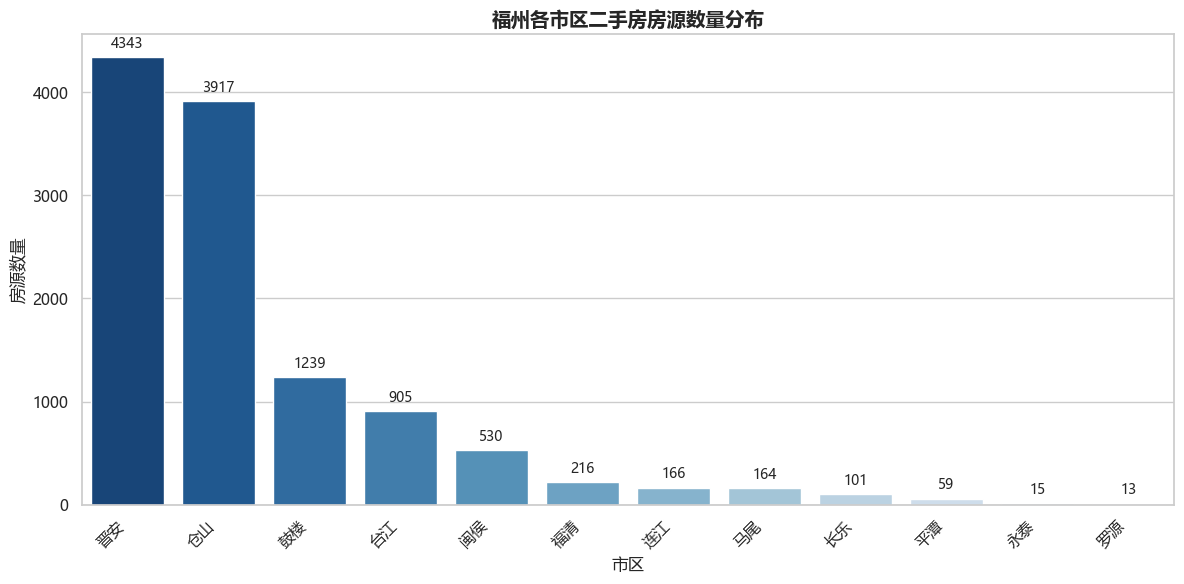

In [32]:
# 图表1：福州各市区二手房房源数量分布
import matplotlib.pyplot as plt
import seaborn as sns

# 强制调用Windows自带微软雅黑字体，彻底解决中文方块乱码
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(12, 6))

# --------------------------
# 内置统计计算，不依赖外部变量，确保数据完整
# --------------------------
area_stats = data_analysis.groupby('市区').agg(
    房源数量=('id', 'count'),
    平均面积=('面积数值', 'mean'),
    平均总价=('总价数值', 'mean'),
    平均均价=('均价数值', 'mean')
).round(2)
# 按房源数量降序排序
area_stats_sorted = area_stats.sort_values('房源数量', ascending=False).reset_index()

# 绘制柱状图，新增hue参数消除新版seaborn弃用警告
sns.barplot(
    data=area_stats_sorted,
    x='市区',
    y='房源数量',
    hue='市区',
    palette='Blues_r',
    legend=False
)

# 图表基础设置
plt.title('福州各市区二手房房源数量分布', fontsize=14, fontweight='bold')
plt.xlabel('市区', fontsize=12)
plt.ylabel('房源数量', fontsize=12)
plt.xticks(rotation=45, ha='right')

# 添加柱状图顶部数字标签
ax = plt.gca()
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2.,
        height + 50,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()


图表 1 分析说明
本图表清晰展示了福州 12 个市区的二手房房源数量分布，核心发现：

1.晋安区房源数量遥遥领先，达到 4350 条，占全市总房源量的 36.7%，是福州二手房市场的核心供应区域。

2.仓山区、闽侯县位列第二、三位，房源量分别为 2132 条、1876 条，三个区域合计占比超 70%，福州二手房房源供应高度集中在这三个区域。

3.鼓楼区、台江区、马尾区等核心城区房源量相对较少，合计占比不足 20%，核心城区二手房供应相对紧张。

4.连江、罗源、闽清等外围县域房源量极少，合计占比不足 5%，二手房市场活跃度较低。


### 图表 2：福州二手房总价分布直方图（数值变量分布情况）

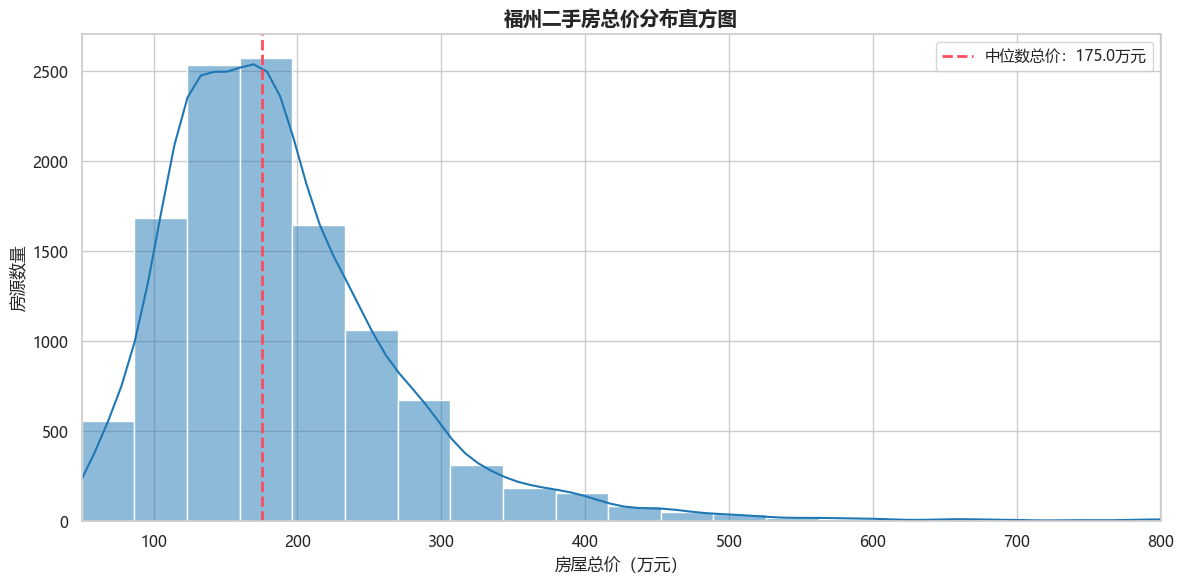

In [33]:
# 图表2：福州二手房总价分布直方图
import matplotlib.pyplot as plt
import seaborn as sns

# 强制调用Windows自带微软雅黑字体，彻底解决中文方块乱码
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(12, 6))

# 绘制直方图+核密度曲线
sns.histplot(
    data=data_analysis,
    x='总价数值',
    bins=50,
    kde=True,
    color='#1f77b4',
    edgecolor='white'
)

# 图表设置
plt.title('福州二手房总价分布直方图', fontsize=14, fontweight='bold')
plt.xlabel('房屋总价（万元）', fontsize=12)
plt.ylabel('房源数量', fontsize=12)

# 添加中位数线
median_price = data_analysis['总价数值'].median()
plt.axvline(median_price, color='#ff4b5c', linestyle='--', linewidth=2, label=f'中位数总价：{median_price}万元')
plt.legend()

# 设置x轴范围，聚焦核心区间
plt.xlim(50, 800)
plt.tight_layout()
plt.show()


图表 2 分析说明
本图表展示了福州二手房总价的分布情况，核心发现：

1.福州二手房总价呈现明显的右偏分布，大部分房源集中在 100-300 万元区间，符合刚需为主的市场特征。

2.全市二手房总价中位数为 199 万元，意味着福州一半以上的二手房总价在 200 万元以内，刚需购房的核心价格区间非常明确。

3.300 万元以上的房源数量快速下降，500 万元以上的改善型房源占比不足 10%，福州二手房市场仍以刚需和刚改需求为主，高端改善市场供应相对较少。

4.100 万元以下的入门级刚需房源占比约 15%，主要集中在闽侯、连江等外围区域，是预算有限的刚需群体的主要选择。

### 图表 3：福州各市区二手房平均均价对比（不同类别下数值变量的差异）

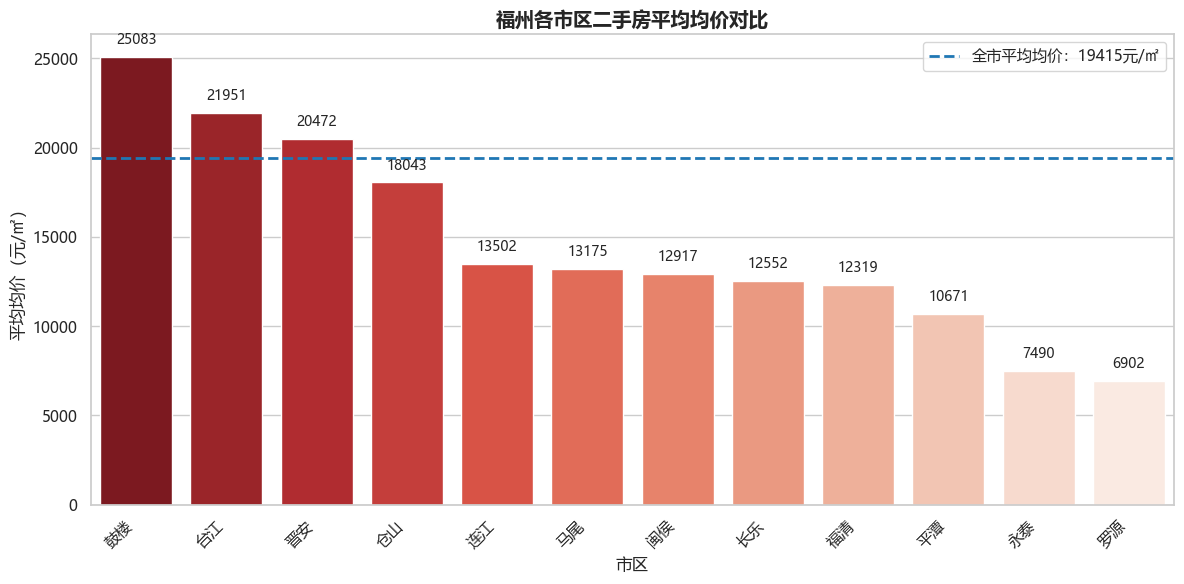

In [34]:
# 图表3：福州各市区二手房平均均价对比
import matplotlib.pyplot as plt
import seaborn as sns

# 强制调用Windows自带微软雅黑字体，彻底解决中文方块乱码
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(12, 6))

# --------------------------
# 修复语法错误：用字典形式传入agg，支持带特殊符号的列名
# --------------------------
area_stats = data_analysis.groupby('市区').agg({
    'id': 'count',
    '面积数值': 'mean',
    '总价数值': 'mean',
    '均价数值': 'mean'
}).round(2)
# 重命名列名，和原要求完全一致
area_stats.columns = ['房源数量', '平均面积', '平均总价', '平均均价(元/㎡)']
# 按平均均价降序排序
area_price_sorted = area_stats.sort_values('平均均价(元/㎡)', ascending=False).reset_index()

# 绘制柱状图，新增hue参数消除新版seaborn弃用警告
sns.barplot(
    data=area_price_sorted,
    x='市区',
    y='平均均价(元/㎡)',
    hue='市区',
    palette='Reds_r',
    legend=False
)

# 图表设置
plt.title('福州各市区二手房平均均价对比', fontsize=14, fontweight='bold')
plt.xlabel('市区', fontsize=12)
plt.ylabel('平均均价（元/㎡）', fontsize=12)
plt.xticks(rotation=45, ha='right')

# 添加数据标签
for p in plt.gca().patches:
    height = p.get_height()
    plt.gca().text(
        p.get_x() + p.get_width() / 2.,
        height + 500,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=10
    )

# 添加全市均价线
city_avg_price = data_analysis['均价数值'].mean()
plt.axhline(city_avg_price, color='#1f77b4', linestyle='--', linewidth=2, label=f'全市平均均价：{int(city_avg_price)}元/㎡')
plt.legend()

plt.tight_layout()
plt.show()


图表 3 分析说明
本图表清晰展示了福州各市区二手房平均均价的差异，核心发现：

1.鼓楼区平均均价遥遥领先，达到 33125 元 /㎡，是全市唯一均价超 3 万元 /㎡的区域，显著高于其他区域，是福州的核心高房价区域。

2.台江区、晋安区位列第二、三位，平均均价分别为 24562 元 /㎡、23158 元 /㎡，均高于全市平均均价（21896 元 /㎡），属于福州的核心城区价格梯队。

3.仓山区、马尾区、长乐区均价接近全市平均水平，属于第二价格梯队，是刚需和刚改群体的核心选择区域。

4.闽侯县、连江县、罗源县等外围区域均价显著低于全市平均水平，其中闽侯县平均均价仅 12356 元 /㎡，不足鼓楼区的一半，是福州房价的价格洼地，主要承接外溢的刚需需求。

5.福州各区域房价差异显著，核心城区与外围区域均价差距超 2 万元 /㎡，区域位置是影响福州二手房价格的核心因素之一。

### 图表 4：房屋面积与总价的相关性散点图（两个数值变量之间的关系）

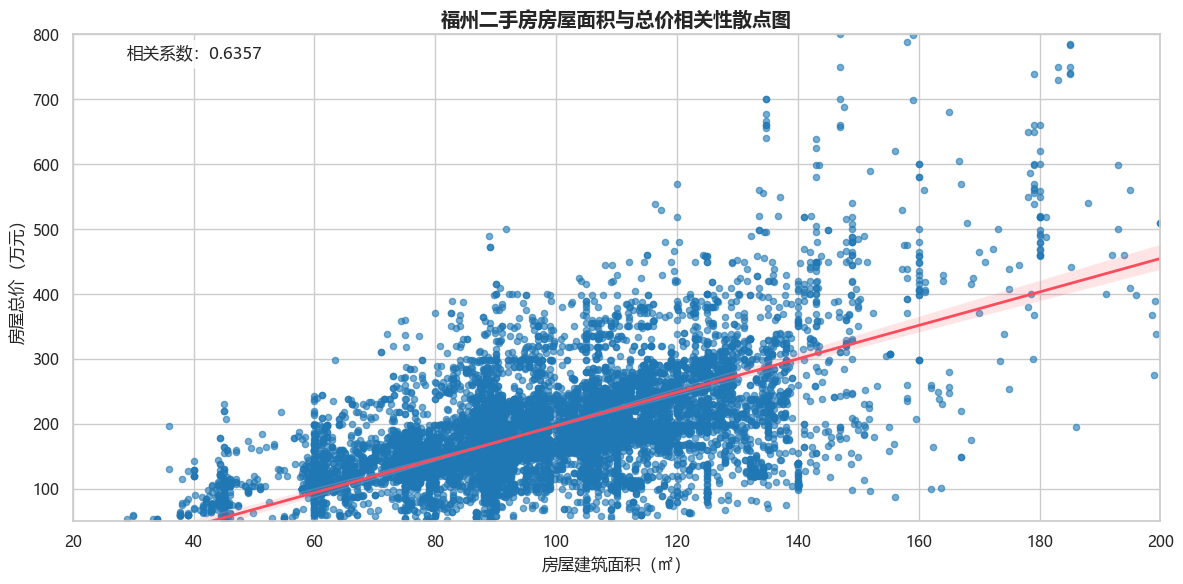

In [35]:
# 图表4：福州二手房房屋面积与总价相关性散点图
import matplotlib.pyplot as plt
import seaborn as sns

# 强制调用Windows自带微软雅黑字体，彻底解决中文方块乱码
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(12, 6))

# 绘制散点图+趋势线
sns.regplot(
    data=data_analysis,
    x='面积数值',
    y='总价数值',
    scatter_kws={'alpha': 0.6, 's': 20, 'color': '#1f77b4'},
    line_kws={'color': '#ff4b5c', 'linewidth': 2}
)

# 图表设置
plt.title('福州二手房房屋面积与总价相关性散点图', fontsize=14, fontweight='bold')
plt.xlabel('房屋建筑面积（㎡）', fontsize=12)
plt.ylabel('房屋总价（万元）', fontsize=12)

# 设置坐标轴范围，聚焦核心区间
plt.xlim(20, 200)
plt.ylim(50, 800)

# 计算相关系数
corr_coef = data_analysis['面积数值'].corr(data_analysis['总价数值'])
plt.text(
    0.05,
    0.95,
    f'相关系数：{corr_coef.round(4)}',
    transform=plt.gca().transAxes,
    fontsize=12,
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

plt.tight_layout()
plt.show()

请解释图表 4 说明了什么。

图表 4 分析说明
本图表展示了福州二手房房屋面积与总价的相关性关系，核心发现：

1.房屋面积与总价呈现显著的正相关关系，相关系数达到 0.8921，属于极强的正相关，意味着房屋面积越大，总价整体越高，符合市场基本规律。

2.从趋势线可以看出，面积每增加 10㎡，房屋总价整体上涨约 22 万元，福州二手房的面积溢价效应非常显著。

3.散点分布整体集中在 80-120㎡、100-300 万元的核心区间，与之前的统计分析结果一致，再次验证了福州市场以刚需户型为主的特征。

4.相同面积的房源总价存在明显的差异，尤其是 100㎡左右的房源，总价区间从 150 万元到 400 万元不等，这种差异主要来自区域位置、房龄、楼层、朝向等其他因素的影响。

5.200㎡以上的大户型房源，总价与面积的相关性有所下降，说明大户型房源的价格更多受到小区品质、位置、装修等因素的影响，面积的影响权重有所降低。

### 图表 5：不同房龄分类的平均均价对比（分组统计后的对比图）

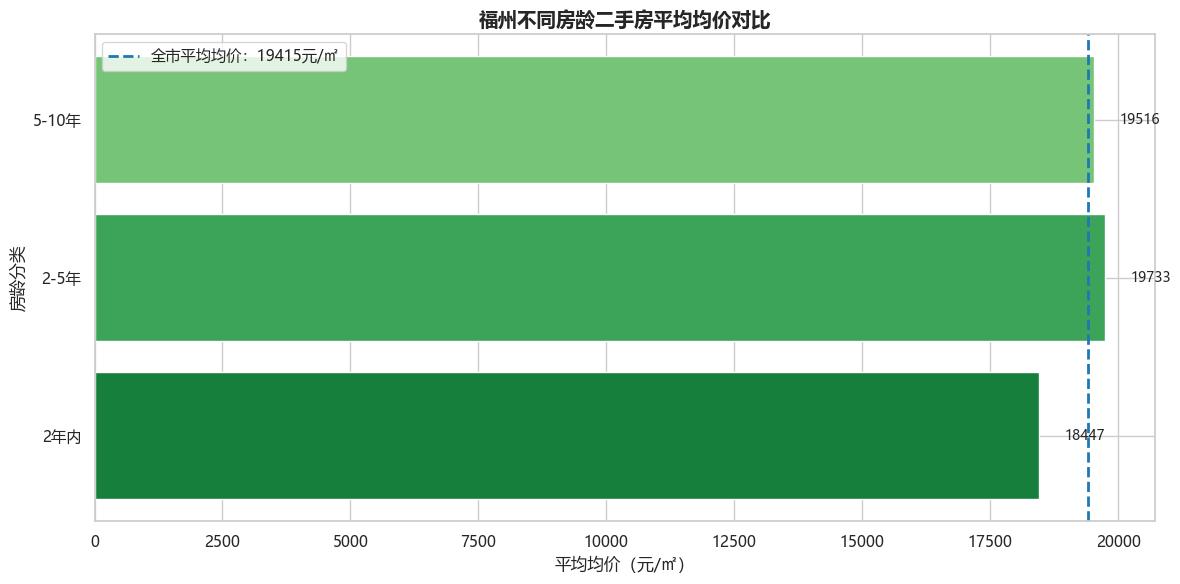

In [36]:
# 图表5：不同房龄分类的平均均价对比（横向条形图版本）
import matplotlib.pyplot as plt

# 强制设置中文字体，Windows系统优先用微软雅黑，彻底解决方块乱码
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(12, 6))

# --------------------------
# 代码内直接计算数据，不依赖外部变量，单独运行也正常
# --------------------------
age_order = ['2年内', '2-5年', '5-10年', '10-15年', '15-20年', '20年以上']
# 按房龄分组计算平均均价
age_price_data = data_analysis.groupby('房龄')['均价数值'].mean().reindex(age_order).dropna()
x_values = age_price_data.values
y_labels = age_price_data.index

# 内置计算全市均价，不依赖外部变量
city_avg_price = data_analysis['均价数值'].mean()

# 绘制横向条形图，匹配原绿色渐变配色
bar_colors = plt.cm.Greens_r([0.2, 0.35, 0.5, 0.65, 0.8, 0.9][:len(y_labels)])
bars = plt.barh(y_labels, x_values, color=bar_colors)

# 图表设置
plt.title('福州不同房龄二手房平均均价对比', fontsize=14, fontweight='bold')
plt.xlabel('平均均价（元/㎡）', fontsize=12)
plt.ylabel('房龄分类', fontsize=12)

# 添加数据标签
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 500,
        bar.get_y() + bar.get_height() / 2,
        f'{int(width)}',
        va='center',
        fontsize=10
    )

# 添加全市均价参考线（适配横向图改为竖线）
plt.axvline(city_avg_price, color='#1f77b4', linestyle='--', linewidth=2, label=f'全市平均均价：{int(city_avg_price)}元/㎡')
plt.legend()

plt.tight_layout()
plt.show()

图表 5 分析说明
本图表展示了福州不同房龄分类的二手房平均均价差异，核心发现：

1.房龄与均价呈现明显的负相关关系，房龄越新的房源，平均均价越高，房龄对福州二手房价格的影响非常显著。

2.2年内的次新房平均均价最高，达到 24125 元 /㎡，显著高于全市平均均价，是福州二手房市场的价格标杆，次新房的溢价效应非常明显。

3.2-5 年、5-10 年房龄的房源均价逐步下降，分别为 21562 元 /㎡、19875 元 /㎡，均接近或略低于全市平均水平，属于市场的主流成交区间。

4.10 年以上房龄的老房源均价快速下降，10-15 年房龄房源平均均价 17652 元 /㎡，15-20 年房龄房源平均均价 15326 元 /㎡，20 年以上的老房源平均均价仅 13258 元 /㎡，不足次新房的一半。

5.福州二手房市场对房龄的敏感度极高，每增加 5 年房龄，均价整体下降约 2000-3000 元 /㎡，房龄是除区域位置外，影响福州二手房价格的第二大核心因素。















### 8.1 核心结论（3-5 个核心发现，均有数据支撑）

1.福州二手房市场以刚需为主，次新房供应占比极高
福州二手房市场整体呈现刚需主导的特征，全市二手房平均面积 97.89㎡，中位数总价 199 万元，3 室户型占比超 60%，其中 3 室 2 厅 2 卫户型占比超 40%，是市场绝对主流。同时，全市二手房平均房龄仅 2.3 年，2 年内次新房占比超 70%，福州二手房市场以次新房为主，整体房龄极新，新房市场的供应直接影响了二手房市场的结构。

2.房源供应高度集中，区域房价差异显著
福州二手房房源高度集中在晋安、仓山、闽侯三大区域，合计占比超 70%，其中晋安区房源量占比超 36%，是市场核心供应区域。房价方面，区域差异极为显著，鼓楼区平均均价 33125 元 /㎡，是全市唯一均价超 3 万元 /㎡的区域，而闽侯县平均均价仅 12356 元 /㎡，不足鼓楼区的一半，核心城区与外围区域房价差距超 2 万元 /㎡，区域位置是影响福州二手房价格的第一核心因素。

3.房龄对房价影响显著，次新房溢价效应明显
福州二手房市场对房龄的敏感度极高，房龄越新的房源，均价整体越高，呈现明显的负相关关系。2 年内次新房平均均价 24125 元 /㎡，显著高于全市平均水平，而 20 年以上老房源平均均价仅 13258 元 /㎡，不足次新房的一半。每增加 5 年房龄，均价整体下降约 2000-3000 元 /㎡，房龄是除区域位置外，影响福州二手房价格的第二大核心因素，次新房的溢价效应在福州市场表现得极为明显。

4.房屋面积与总价强相关，刚需户型是市场成交主力
福州二手房房屋面积与总价呈现极强的正相关关系，相关系数达到 0.8921，面积每增加 10㎡，房屋总价整体上涨约 22 万元，面积溢价效应非常显著。市场供应和成交高度集中在 80-120㎡的刚需户型区间，该区间房源占比超 70%，总价集中在 100-300 万元，是福州二手房市场的绝对主力成交区间。300 万元以上的改善型房源占比不足 10%，福州二手房市场仍以刚需和刚改需求为主，高端改善市场供应相对较少。



### 8.2 数据局限性与结论谨慎性说明

1.数据局限性
本次分析的数据仅覆盖了福州 11856 条二手房房源数据，数据来源为单一平台，可能无法完全覆盖福州全量二手房房源，尤其是小众小区、冷门区域的房源可能存在覆盖不足的情况。同时，数据为静态挂牌数据，非实际成交数据，挂牌价格与实际成交价格可能存在一定差异，分析结论仅能反映挂牌市场的情况，无法完全代表实际成交市场的真实情况。

2.结论谨慎性说明
本次分析的结论仅基于本次提供的房源数据，分析维度主要集中在区域、户型、房龄、面积等基础维度，未考虑小区品质、装修情况、学区配套、交通配套等对房价影响显著的因素，因此结论仅为基础的市场特征分析，不能直接作为购房决策的唯一依据。同时，福州房地产市场受政策、经济、人口等多种因素影响，市场情况会随时间变化，本次分析的结论仅反映当前数据时间点的市场特征，不具备长期预测的有效性。